# Config & Setup

In [1]:
%%capture
!pip install -U "datasets<3.0.0"

### Imports

In [2]:
import re # regular expressions
import math # math utilities
import random # randomly seeding
from collections import Counter # count token frequency
from collections import defaultdict
import string
import datasets
import matplotlib.pyplot as plt

import torch # PyTorch tensor library
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader # dataset and batching

# parallelizing for faster training
import os
import itertools

torch.set_float32_matmul_precision('high')

In [3]:
# seeding random numbers for reproducibility
random.seed(42)
torch.manual_seed(42)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"  # choose device
print("Using device:", device)

Using device: cuda


In [5]:
CONFIG = {
    "vocab_size": 0,
    "context_length": 256,
    "emb_dim": 256,
    "n_heads": 8,
    "n_layers": 4,
    "drop_rate": 0.1,
    "qkv_bias": False,
    "batch_size": 256,
    "learning_rate": 5e-4,
    "max_steps": 3000
}

print("Config:", CONFIG)

Config: {'vocab_size': 0, 'context_length': 256, 'emb_dim': 256, 'n_heads': 8, 'n_layers': 4, 'drop_rate': 0.1, 'qkv_bias': False, 'batch_size': 256, 'learning_rate': 0.0005, 'max_steps': 3000}


# Data Pipeline

In [6]:
year_1993_training_dataset, year_1993_test_dataset = datasets.load_dataset(
    "eloukas/edgar-corpus",
    "year_1993",
    split=["train","test"],
    trust_remote_code=True
)

Generating train split:   0%|          | 0/1060 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/133 [00:00<?, ? examples/s]

In [7]:
class SECRegexTokenizer:
    def __init__(self):
        self.vocab = {}
        self.inv_vocab = {}

    def _tokenize_text(self, text):
        # Base regex splitting logic
        tokens = re.split(r"([,.:;?_!/\"()'\-]|\s+)", text)
        return [t.strip() for t in tokens if t.strip()]

    def build_vocab(self, corpus_texts):
        print("Building vocabulary...")

        all_tokens = []
        for text in corpus_texts:
            all_tokens.extend(self._tokenize_text(text))

        unique = sorted(set(all_tokens))
        self.vocab = {tok: i for i, tok in enumerate(unique)}

        special_tokens = ['<|unk|>', '<|endoftext|>', '[BOS]', '[EOS]', '[PAD]']
        for tok in special_tokens:
            if tok not in self.vocab:
                new_token_id = len(self.vocab)
                self.vocab[tok] = new_token_id

        self.inverse_vocab = {i: tok for tok, i in self.vocab.items()}
        print(f"Vocabulary built! Size: {len(self.vocab)}")


    def encode(self, text, unk_token='<|unk|>'):
        toks = self._tokenize_text(text) # Tokenize the new input text
        unk_id = self.vocab[unk_token] # Get the ID for the unknown tokens
        ids = [self.vocab.get(t, unk_id) for t in toks] # We use vocab.get to fall back to unk_id
        return ids, toks

    def decode(self, ids):
        toks = [self.inverse_vocab[i] for i in ids] # map each ID to its token
        text = ' '.join(toks) # join tokens with spaces
        text = re.sub(r"\s+([,.:;?_!/\"()'])", r"\1", text)
        text = re.sub(r"\s+\-", "-", text)
        return text

class EDGARDataset(torch.utils.data.Dataset):
    def __init__(self, data_tokens, context_length):
        self.data = data_tokens
        self.context_length = context_length

    def __len__(self):
        return len(self.data) - self.context_length

    def __getitem__(self, idx):
        # Returns (Context, Target) pairs
        chunk = self.data[idx : idx + self.context_length + 1]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        return x, y

# Model Architecture

In [8]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim: int, eps: float = 1e-5):
        super().__init__()  # initialize base class

        self.eps = eps  # numerical stability term

        # Learnable parameters: scale (gamma) and shift (beta)
        self.gamma = nn.Parameter(torch.ones(emb_dim))  # [D]
        self.beta = nn.Parameter(torch.zeros(emb_dim))  # [D]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, D]

        # Compute mean over the feature dimension D
        mean = x.mean(dim=-1, keepdim=True)  # [B, T, 1]

        # Compute variance over the feature dimension D
        var = x.var(dim=-1, keepdim=True, unbiased=False)  # [B, T, 1]

        # Normalize
        x_hat = (x - mean) / torch.sqrt(var + self.eps)  # [B, T, D]

        # Scale and shift (broadcast gamma/beta over B and T)
        out = self.gamma * x_hat + self.beta  # [B, T, D]

        return out

In [9]:
class FeedForward(nn.Module):
    def __init__(self, emb_dim: int, drop_rate: float):
        super().__init__()  # initialize

        # Two-layer MLP with GELU in between
        self.net = nn.Sequential(
            nn.Linear(emb_dim, 4 * emb_dim),  # expand features
            nn.GELU(),                        # nonlinearity
            nn.Linear(4 * emb_dim, emb_dim),  # project back to emb_dim
            nn.Dropout(drop_rate)             # dropout for regularization
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, D]
        return self.net(x)  # [B, T, D]

In [10]:
class MultiHeadCausalSelfAttention(nn.Module):
    # Multi-head causal self-attention (scaled dot-product)
    def __init__(self, emb_dim: int, num_heads: int, context_length: int, drop_rate: float, qkv_bias: bool):
        super().__init__()  # init

        assert emb_dim % num_heads == 0  # ensure heads divide embedding dim

        self.emb_dim = emb_dim  # embedding dimension D
        self.num_heads = num_heads  # number of heads H
        self.head_dim = emb_dim // num_heads  # per-head dim

        # Linear projections for Q, K, V (each produces D features)
        self.Wq = nn.Linear(emb_dim, emb_dim, bias=qkv_bias)
        self.Wk = nn.Linear(emb_dim, emb_dim, bias=qkv_bias)
        self.Wv = nn.Linear(emb_dim, emb_dim, bias=qkv_bias)

        # Output projection back to emb_dim
        self.out_proj = nn.Linear(emb_dim, emb_dim, bias=True)

        # Dropout on attention weights
        self.attn_drop = nn.Dropout(drop_rate)

        # Register a causal mask as a non-parameter buffer
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length, dtype=torch.bool), diagonal=1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, D]
        B, T, D = x.shape  # unpack

        # Project to Q, K, V: [B, T, D]
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        # Reshape into heads: [B, T, D] -> [B, H, T, head_dim]
        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        # Scores: [B, H, T, T]
        scores = Q @ K.transpose(-2, -1)

        # Scale scores for stability
        scores = scores / math.sqrt(self.head_dim)

        # Apply causal mask (slice to current T)
        mask = self.mask[:T, :T]
        scores = scores.masked_fill(mask, -torch.inf)

        # Softmax over last dim to get attention weights
        weights = torch.softmax(scores, dim=-1)

        # Apply dropout to attention weights
        weights = self.attn_drop(weights)

        # Context per head: [B, H, T, head_dim]
        context = weights @ V

        # Recombine heads: [B, H, T, head_dim] -> [B, T, D]
        context = context.transpose(1, 2).contiguous().view(B, T, D)

        # Final projection: [B, T, D]
        out = self.out_proj(context)

        return out

In [11]:
class TransformerBlock(nn.Module):
    # GPT-2 style Pre-LN transformer block: (Attn + FFN) with residual connections
    def __init__(self, cfg):
        super().__init__()  # init

        D = cfg["emb_dim"]  # embedding dim

        # Pre-LN layers
        self.ln1 = LayerNorm(D)
        self.ln2 = LayerNorm(D)

        # Causal multi-head attention
        self.attn = MultiHeadCausalSelfAttention(
            emb_dim=D,
            num_heads=cfg["n_heads"],
            context_length=cfg["context_length"],
            drop_rate=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )

        # Feed-forward network
        self.ff = FeedForward(D, cfg["drop_rate"])

        # Dropout on residual branches (common in GPT-style)
        self.resid_drop = nn.Dropout(cfg["drop_rate"])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, D]

        # Attention block (Pre-LN) + residual
        x = x + self.resid_drop(self.attn(self.ln1(x)))

        # Feed-forward block (Pre-LN) + residual
        x = x + self.resid_drop(self.ff(self.ln2(x)))

        return x

In [12]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()  # init

        self.cfg = cfg  # store cfg

        # Embeddings
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Transformer blocks
        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        # Final normalization
        self.final_ln = LayerNorm(cfg["emb_dim"])

        # Output head (logits over vocab)
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        # idx: [B, T]
        B, T = idx.shape  # unpack

        # Token embeddings: [B, T, D]
        tok = self.tok_emb(idx)

        # Positional embeddings: [T, D]
        pos_ids = torch.arange(T, device=idx.device)
        pos = self.pos_emb(pos_ids)

        # Combine + dropout: [B, T, D]
        x = self.drop_emb(tok + pos)

        # Pass through transformer blocks
        for block in self.blocks:
            x = block(x)

        # Final norm
        x = self.final_ln(x)

        # Output logits: [B, T, V]
        logits = self.out_head(x)

        return logits

# Execution

In [13]:
def estimate_loss(model, val_dataloader, eval_batches=50):
    model.eval()
    batch_losses = []
    with torch.no_grad():
        # Add autocast for fast evaluation
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16): #bfloat16: less precision than float32, optimized for deep learning
            for i, (X, y) in enumerate(val_dataloader):
                if i >= eval_batches: # STOP after 50 batches
                    break
                X, y = X.to(device), y.to(device)
                logits = model(X).view(-1, model.cfg["vocab_size"])
                loss = torch.nn.functional.cross_entropy(logits, y.view(-1))
                batch_losses.append(loss.item())
    model.train()
    return sum(batch_losses) / len(batch_losses) if batch_losses else 0


def generate_text(model, starting_tokens, max_new_tokens):
    """argmax greedy text generation"""
    model.eval()
    for _ in range(max_new_tokens):
        tokens_cond = starting_tokens[:, -model.cfg["context_length"]:]
        with torch.no_grad():
            logits = model(tokens_cond)
        next_id = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        starting_tokens = torch.cat([starting_tokens, next_id], dim=1)
    return starting_tokens


def prepare_data(train_data, val_data):
    # Initialize Tokenizer & Build Vocab
    tokenizer = SECRegexTokenizer()
    train_texts = [feature['section_1'] for feature in train_data]
    tokenizer.build_vocab(train_texts)

    # Update Model Config
    vocab_size = len(tokenizer.vocab)
    print(f"Updated CONFIG: {CONFIG}")

    # Flatten and Tokenize Data (PARALLELIZED)
    print("Tokenizing data using multiprocessing...")
    eos_id = tokenizer.vocab['<|endoftext|>']

    def process_batch(examples):
        batch_ids = []
        for text in examples['section_1']:
            ids, _ = tokenizer.encode(text)
            batch_ids.append(ids + [eos_id])
        return {"flat_ids": batch_ids}

    # Map across all available CPU cores
    tokenized_train = train_data.map(
        process_batch, # flatten batch of ids and insert eos_id in between
        batched=True,
        num_proc=20, # parallelize
        desc="Tokenizing Train Data"
    )

    all_train_tokens = list(itertools.chain.from_iterable(tokenized_train["flat_ids"]))

    tokenized_val = val_data.map(
        process_batch,
        batched=True,
        num_proc=20,
        desc="Tokenizing Val Data"
    )

    all_val_tokens = list(itertools.chain.from_iterable(tokenized_val["flat_ids"]))

    return all_train_tokens, all_val_tokens, tokenizer, vocab_size


def create_dataloaders(train_tokens, val_tokens, config, cores):

    print(f"Spinning up {min(8, cores)} DataLoader workers...") # 8 or 4 is good

    train_dataset = EDGARDataset(train_tokens, CONFIG["context_length"])
    train_dataloader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        num_workers=min(8, cores),     # Fetch data using background CPU cores
        pin_memory=True                # Speeds up CPU-to-GPU transfer
    )

    val_dataset = EDGARDataset(val_tokens, CONFIG["context_length"])
    val_dataloader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        num_workers=min(8, cores),
        pin_memory=True
    )

    return train_dataloader, val_dataloader


def train(model, train_loader, val_loader, optimizer, config, eval_every=100, num_epochs=1, max_steps=1500):

    # Training Loop
    step = 0
    train_losses, val_losses = [], []
    for epoch in range(num_epochs):

        for X, y in train_loader:
            step += 1

            # tensor.to(device, non_blocking=True) starts moving stuff to the GPU in
            # the background and goes on to the next line of code
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

            optimizer.zero_grad() # Reset Gradients

            # Automatic Mixed Precision (bfloat16 for H100)
            # casts parameters into optimized dtypes for computational efficiency
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                logits = model(X).view(-1, CONFIG["vocab_size"])
                loss = torch.nn.functional.cross_entropy(logits, y.view(-1))

            loss.backward() # Back propagation
            optimizer.step() # Update parameters

            if step % eval_every == 0:
                val_loss = estimate_loss(model, val_loader)
                val_losses.append(val_loss)
                train_loss = loss.item()
                train_losses.append(train_loss)
                print(f"Epoch {epoch} | Step {step} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

            if step >= max_steps:
                print(f"Reached max_steps ({max_steps}). Stopping training early.")
                return train_losses, val_losses

    return train_losses, val_losses

Building vocabulary...
Vocabulary built! Size: 47319
Updated CONFIG: {'vocab_size': 0, 'context_length': 256, 'emb_dim': 256, 'n_heads': 8, 'n_layers': 4, 'drop_rate': 0.1, 'qkv_bias': False, 'batch_size': 256, 'learning_rate': 0.0005, 'max_steps': 3000}
Tokenizing data using multiprocessing...


Tokenizing Train Data (num_proc=20):   0%|          | 0/1060 [00:00<?, ? examples/s]

Tokenizing Val Data (num_proc=20):   0%|          | 0/133 [00:00<?, ? examples/s]

Updated CONFIG: {'vocab_size': 47319, 'context_length': 256, 'emb_dim': 256, 'n_heads': 8, 'n_layers': 4, 'drop_rate': 0.1, 'qkv_bias': False, 'batch_size': 256, 'learning_rate': 0.0005, 'max_steps': 3000}
Spinning up 8 DataLoader workers...
Compiling model for GPU Arhcitecture...
Epoch 0 | Step 100 | Train loss: 6.1620 | Val loss: 6.2939
Epoch 0 | Step 200 | Train loss: 5.5825 | Val loss: 5.7561
Epoch 0 | Step 300 | Train loss: 5.3236 | Val loss: 5.4783
Epoch 0 | Step 400 | Train loss: 5.0770 | Val loss: 5.2377
Epoch 0 | Step 500 | Train loss: 4.8620 | Val loss: 5.0516
Epoch 0 | Step 600 | Train loss: 4.7042 | Val loss: 4.9154
Epoch 0 | Step 700 | Train loss: 4.4783 | Val loss: 4.8022
Epoch 0 | Step 800 | Train loss: 4.3990 | Val loss: 4.6732
Epoch 0 | Step 900 | Train loss: 4.2715 | Val loss: 4.5720
Epoch 0 | Step 1000 | Train loss: 4.1444 | Val loss: 4.4867
Epoch 0 | Step 1100 | Train loss: 4.0656 | Val loss: 4.4085
Epoch 0 | Step 1200 | Train loss: 4.0051 | Val loss: 4.3264
Epoch 0

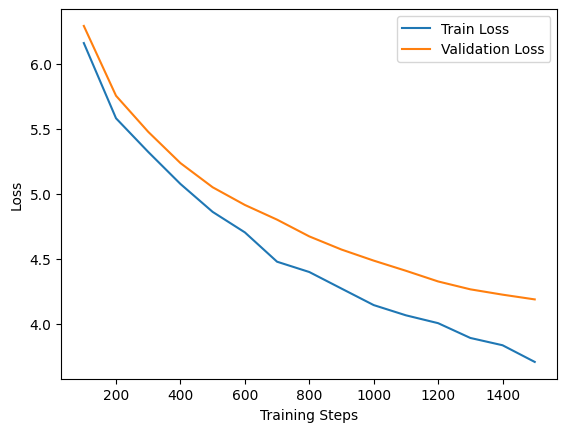

Train/Val Losses: 3.71/4.19
Train/Val Perplexity: 40.72/65.89


/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


Prompt: The company has a 
Output: The company has a number of patents and trademarks, including the company, and its subsidiaries. The company' s principal business is highly competitive. The company' s principal competitors are highly competitive. The company' s principal competitors

Prompt: Net income for the year was 
Output: Net income for the year was approximately $2. 0 million, and $1. 0 million, respectively. The Company' s investment portfolio is subject to the Company' s income and income tax returns. The Company' s investment income is

Prompt: The board of directors 
Output: The board of directors and directors of directors of directors and officers of directors and officers of directors of the Company. The Company has not been named as a result of the Company' s Board of Directors. The Company has not

Prompt: According to the financial statements, 
Output: According to the financial statements, the Company has not been able to be able to be able to be material. The Comp

In [14]:
def main():

    ### Tokenize Dataset ###

    all_train_tokens, all_val_tokens, tokenizer, vocab_size = prepare_data(year_1993_training_dataset, year_1993_test_dataset)

    CONFIG["vocab_size"] = vocab_size
    print(f"Updated CONFIG: {CONFIG}")

    ### Initialize Dataloaders ###

    train_dataloader, val_dataloader = create_dataloaders(all_train_tokens, all_val_tokens, CONFIG, cores=8)

    ### Initialize Model & Optimzer ###

    model = GPTModel(CONFIG).to(device)

    print("Compiling model for GPU Arhcitecture...")
    model = torch.compile(model)

    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])

    ### Training Loop ###

    EVAL_EVERY = 100

    train_losses, val_losses = train(
        model=model,
        train_loader=train_dataloader,
        val_loader=val_dataloader,
        optimizer=optimizer,
        config=CONFIG,
        eval_every=EVAL_EVERY,
        num_epochs=1,
        max_steps=1500
    )

    print("Pipeline run complete!")

    ### Save Model ###

    PATH = "milestone_2_model.pth"
    torch.save(model.state_dict(), PATH)
    print("Model saved to", PATH)

    ### Plotting ###

    steps_index = [i * EVAL_EVERY for i in range(1, len(val_losses) + 1)]

    plt.plot(steps_index, train_losses, label="Train Loss")
    plt.plot(steps_index, val_losses, label="Validation Loss")

    plt.xlabel("Training Steps")
    plt.ylabel("Loss")
    plt.legend()

    plt.savefig("loss_curve.png")

    plt.show()

    ### Loss & Perplexity ###

    val_perplexity = math.exp(val_losses[-1])
    train_perplexity = math.exp(train_losses[-1])

    print(f"Train/Val Losses: {train_losses[-1]:.2f}/{val_losses[-1]:.2f}")
    print(f"Train/Val Perplexity: {train_perplexity:.2f}/{val_perplexity:.2f}")

    ### Test Generation ###

    prompts = [
        "The company has a ",
        "Net income for the year was ",
        "The board of directors ",
        "According to the financial statements, ",
        "Risk factors include "
    ]

    for p in prompts:
        input_ids, _ = tokenizer.encode(p)
        input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)

        # Generate 40 tokens per prompt
        output_tensor = generate_text(model, input_tensor, max_new_tokens=40)
        generated_text = tokenizer.decode(output_tensor[0].tolist())

        print(f"Prompt: {p}")
        print(f"Output: {generated_text}\n")


if __name__ == "__main__":

    main()

# References

1. Karpathy, A. (2023, January 17). *Let's build GPT: from scratch, in code, spelled out* [Video]. YouTube. https://www.youtube.com/watch?v=kCc8FmEb1nY
2. Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). Attention is all you need. *Advances in Neural Information Processing Systems*, *30*.
3. Google. (2026). *Gemini* (Gemini 3.1 Pro) [Large language model]. https://gemini.google.com/

## Note about AI use

I wrote a majority of this code without the use of AI tools using the materials provided in class and during labs. I made use of Google Gemini to understand PyTorch syntax, specifically prompting it to explain only the concepts without generating code for me to use. I also used it to parallelize my execution engine, which was really slow at first, and I was able to significantly speed up the training process, running on an H100 GPU which I accessed through Google Colab Pro.